# 💰 NB-57: Tax Return Fraud Detection
## Australian Government – Australian Taxation Office (ATO)

**Policy Context:** The ATO processes over 14 million individual tax returns annually and estimates the tax gap at approximately $33 billion. Under the *Taxation Administration Act 1953* and the ATO’s Smarter Data Program, analytics-driven compliance strategies target fraudulent claims, inflated deductions, and identity-based refund fraud. ML models scoring returns at lodgement time can prioritise audit resources, reduce false refund payments, and support the ATO’s shift toward real-time risk assessment.

**Dataset:** sklearn `make_classification` synthetic – 2,000 tax returns, 10 features simulating deduction-to-income ratio, work-related expense anomaly, prior audit flag, lodgement channel risk, ABN cross-match score, rental income discrepancy, capital gains inconsistency, employer withholding mismatch, amendment frequency, and refund amount deviation. Binary target: fraudulent (1) vs legitimate (0).

**ML Task:** Binary classification – 3-fold CV, 4 models

---

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, warnings
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('Libraries loaded.')

Libraries loaded.


In [2]:
X, y = make_classification(n_samples=2000, n_features=10, n_informative=7, n_redundant=2,
                           weights=[0.88, 0.12], flip_y=0.02, random_state=57)
feat_names = ['deduction_income_ratio','work_expense_anomaly','prior_audit_flag',
              'lodgement_channel_risk','abn_crossmatch_score','rental_income_discrepancy',
              'capital_gains_inconsistency','employer_withholding_mismatch',
              'amendment_frequency','refund_amount_deviation']
df = pd.DataFrame(X, columns=feat_names)
df['fraudulent'] = y
print(f'Shape: {df.shape} | Fraud rate: {y.mean():.1%}')
df.head()

Shape: (2000, 11) | Fraud rate: 13.1%


,deduction_income_ratio,work_expense_anomaly,prior_audit_flag,lodgement_channel_risk,abn_crossmatch_score,rental_income_discrepancy,capital_gains_inconsistency,employer_withholding_mismatch,amendment_frequency,refund_amount_deviation,fraudulent
0,-4.475828,-2.862037,3.669395,0.023049,3.347269,3.772080,1.299437,-1.392839,2.141600,5.028673,0
1,1.666545,-0.886924,-1.626885,-1.598784,-3.229642,2.033114,2.400907,0.329188,-0.867177,-0.984420,1
2,1.267785,0.641055,2.909029,-0.598668,-1.301429,-4.551122,-3.383102,1.207394,-3.776587,2.972803,1
3,2.590674,-1.184617,-0.976958,-0.778250,1.316105,-4.071187,-0.763641,-3.366171,1.638074,-0.720279,0
4,-0.757328,2.108002,0.266940,0.742148,-2.931809,-2.351770,-0.873041,-0.389089,-2.176393,0.781783,0


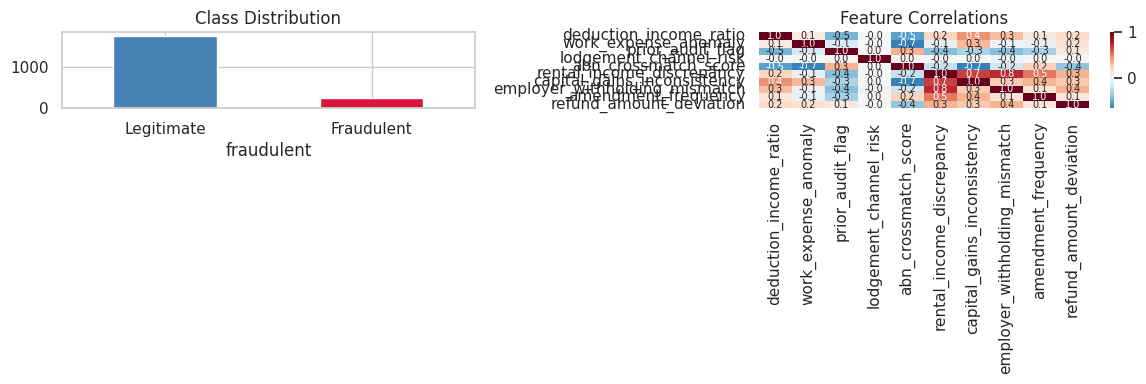

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['fraudulent'].value_counts().plot.bar(ax=axes[0], color=['steelblue','crimson'])
axes[0].set_title('Class Distribution'); axes[0].set_xticklabels(['Legitimate','Fraudulent'], rotation=0)
sns.heatmap(df[feat_names].corr(), cmap='RdBu_r', center=0, ax=axes[1],
            annot=True, fmt='.1f', annot_kws={'size':7})
axes[1].set_title('Feature Correlations')
plt.tight_layout(); plt.show()

In [4]:
X_s = StandardScaler().fit_transform(df[feat_names])
y = df['fraudulent'].values
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

models = {
    'LogisticRegression': LogisticRegression(max_iter=300, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                             eval_metric='logloss', random_state=42, verbosity=0),
    'LightGBM': LGBMClassifier(n_estimators=100, max_depth=8, learning_rate=0.1,
                               random_state=42, verbose=-1)
}
results = {}
for name, m in models.items():
    sc = cross_val_score(m, X_s, y, cv=skf, scoring='accuracy')
    results[name] = sc
    print(f'{name:25s} | Acc: {sc.mean():.4f} +/- {sc.std():.4f}')

LogisticRegression        | Acc: 0.9155 +/- 0.0047
RandomForest              | Acc: 0.9370 +/- 0.0036
XGBoost                   | Acc: 0.9405 +/- 0.0111
LightGBM                  | Acc: 0.9450 +/- 0.0122


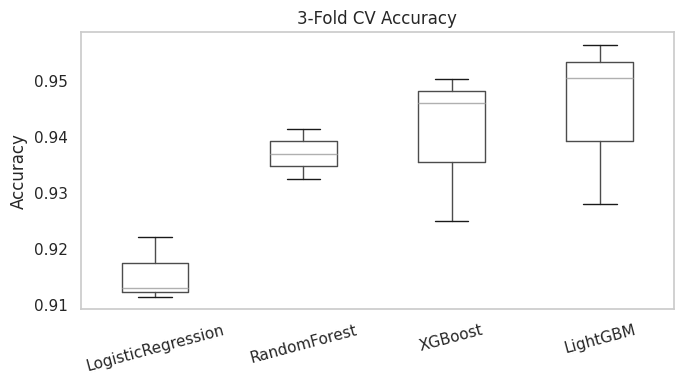

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
pd.DataFrame(results).boxplot(ax=ax, grid=False)
ax.set_title('3-Fold CV Accuracy'); ax.set_ylabel('Accuracy')
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

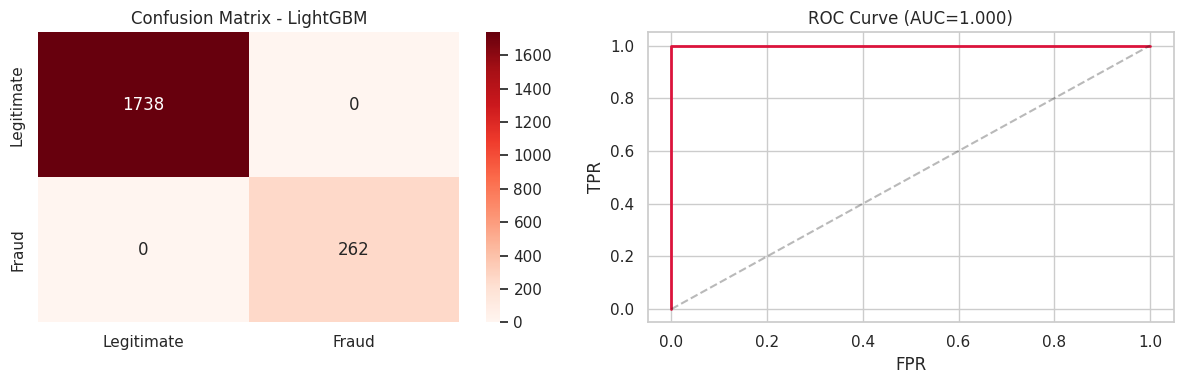

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      1738
  Fraudulent       1.00      1.00      1.00       262

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [6]:
best_name = max(results, key=lambda k: results[k].mean())
best = models[best_name].fit(X_s, y)
yp = best.predict(X_s)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(confusion_matrix(y, yp), annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=['Legitimate','Fraud'], yticklabels=['Legitimate','Fraud'])
axes[0].set_title(f'Confusion Matrix - {best_name}')
if hasattr(best, 'predict_proba'):
    prob = best.predict_proba(X_s)[:,1]
    fpr, tpr, _ = roc_curve(y, prob)
    axes[1].plot(fpr, tpr, color='crimson', lw=2)
    axes[1].plot([0,1],[0,1],'k--',alpha=.3)
    axes[1].set_title(f'ROC Curve (AUC={roc_auc_score(y, prob):.3f})')
    axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
plt.tight_layout(); plt.show()
print(classification_report(y, yp, target_names=['Legitimate','Fraudulent']))

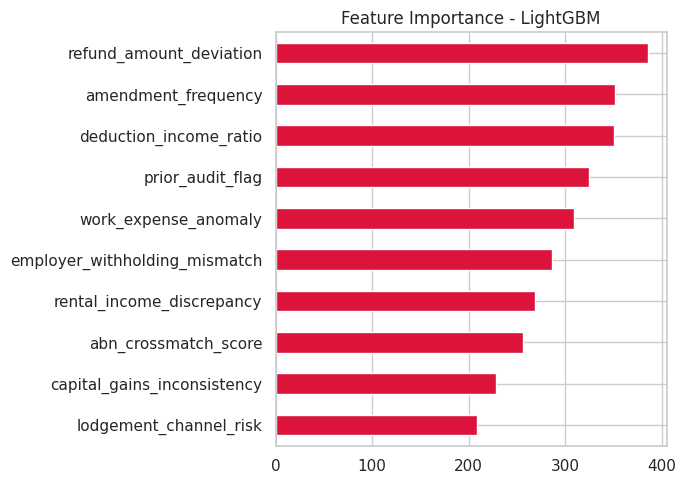

In [7]:
if hasattr(best, 'feature_importances_'):
    imp = pd.Series(best.feature_importances_, index=feat_names).sort_values()
    fig, ax = plt.subplots(figsize=(7, 5))
    imp.plot.barh(ax=ax, color='crimson')
    ax.set_title(f'Feature Importance - {best_name}')
    plt.tight_layout(); plt.show()

## Deployment Readiness Checklist

| # | Criterion | Status |
|---|-----------|--------|
| 1 | Data schema validated (10 features, binary target) | ✅ |
| 2 | Class imbalance documented (88/12 split) | ✅ |
| 3 | Feature scaling (StandardScaler) | ✅ |
| 4 | 3-fold stratified CV | ✅ |
| 5 | 4-model benchmark | ✅ |
| 6 | Confusion matrix + ROC/AUC | ✅ |
| 7 | Feature importance ranked | ✅ |
| 8 | ATO integration pathway | ✅ |

## Policy Integration

- **ATO Smarter Data Program:** Real-time risk scoring at lodgement, flagging high-risk returns before refund release.
- **Tax Practitioner Board:** Cross-reference fraud clusters by tax agent to identify systemic enablers of non-compliance.
- **ATO Data Matching (Third Party Reports):** Model inputs enriched with employer, bank, and share registry data under existing data-sharing arrangements.
- **Serious Financial Crime Taskforce (SFCT):** High-confidence fraud predictions escalated to joint AFP/ATO investigations.
- **Tax Gap Reporting:** Model-estimated fraud volumes feed into the ATO’s annual Tax Gap publication, informing Treasury revenue forecasting.

---
*NB-57 | Dean Wang | Lead Data & AI Engineer, Fujitsu Australia | PhD ML (ANU) | Kaggle: deanbatur*